# Marlim 3 - Tutoriais em Python

# Comparação dos escoamentos multifásicos horizontal e vertical

CVPO - 12/2024

Neste notebook, dois casos base em regime permanente são montados (horizontal e vertical) e, a partir deles, alguns parâmetros do sistema são variados para analisarmos os comportamentos das curvas de escoamento multifásico em cada situação. 

Os exemplos são inspirados na Seção 5.5 de [ANDREOLLI (2016)](https://www.amazon.com.br/Introdu%C3%A7%C3%A3o-Eleva%C3%A7%C3%A3o-Escoamento-Monof%C3%A1sico-Multif%C3%A1sico/dp/857193388X).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import marlim3
import copy

## Introdução

Uma das principais áreas de atuação da disciplina de Elevação e Escoamento (EE) é a modelagem e simulação do processo de escoamento dos fluidos produzidos desde o fundo do poço até a plataforma na superfície, passando pelas linhas submarinas. Modelar esse processo é fundamental, por exemplo, para quantificar a perda de energia do fluido ao longo da tubulação, o que pode gerar a necessidade do uso de métodos de elevação artificial, como o gás-lift ou bombeio submarino. Além disso, a troca térmica do fluido com o entorno da tubulação pode influenciar processos como a formação de hidratos e parafinas, demandando a aplicação de métodos de garantia de escoamento.

Em geral, as três propriedades mais relevantes a serem observadas ao longo de uma simulação de escoamento são: pressão, temperatura e *holdup* de líquido (fração da seção transversal da tubulação ocupada por líquido). Um fator que exerce grande influência é o escorregamento entre as fases, causado pela diferença de velocidades entre elas, o que contribui para perdas de energia no escoamento.

Um importante aspecto do escoamento de petróleo é a presença de múltiplas fases em conjunto, o que caracteriza o escoamento como multifásico. Nesses casos, diversos *arranjos de fases*, ou *padrões de escoamento*, podem surgir em diferentes pontos da tubulação, dependendo principalmente das vazões de cada fase. A seguir, apresentamos uma representação dos arranjos mais comumente observados:

![](https://www.mdpi.com/applsci/applsci-12-08406/article_deploy/html/images/applsci-12-08406-g004.png)

- **Bolha**: caracterizado pela presença de pequenas bolhas de gás dispersas no líquido. O *holdup* é elevado. No caso vertical, ocorre tanto em baixas vazões de líquido (com escorregamento entre as fases) quanto em altas vazões de líquido (neste caso, as bolhas se dispersam no líquido, sem escorregamento significativo). No caso horizontal, esse arranjo se manifesta apenas em altas vazões de líquido.
- **Golfada**: arranjo em que grandes bolhas de gás se formam e se deslocam regularmente pelo líquido.
- **Caótico**: presente apenas no caso vertical, caracteriza uma transição entre a golfada e o próximo arranjo, o anular, conforme se aumenta a vazão de gás.
- **Anular**: arranjo em que o gás escoa pelo centro da tubulação, enquanto o líquido forma um filme na parede. Ocorre para altas vazões de gás.
- **Estratificado**: presente apenas no caso horizontal, caracteriza-se pela separação gravitacional entre gás e líquido. Ocorre para baixas vazões de líquido e de gás. Com o aumento da vazão de gás, a interface entre as fases pode apresentar ondas, resultando no arranjo estratificado ondulado.

No vídeo abaixo, você pode conferir uma interessante visualização dos arranjos de fases em uma tubulação vertical (além de uma trilha sonora bem legalzinha):

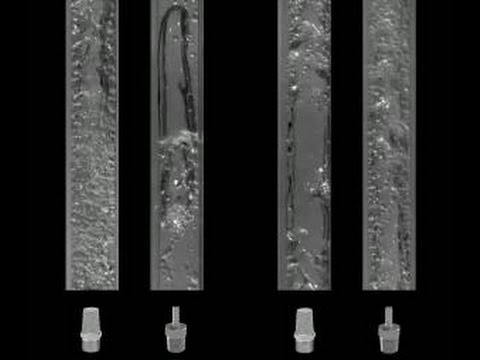

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo("pkhVxqDg_fk")

Neste tutorial, utilizaremos o [**Marlim 3**](https://github.com/petrobras/marlim3), o simulador interno de escoamento multifásico mais avançado da Petrobras, desenvolvido no CENPES, para entender como a coexistência das fases líquido e gás introduz importantes distinções no comportamento do escoamento em tubulações horizontais e verticais. O [**Marlim 3**](https://github.com/petrobras/marlim3) permite a realização de simulações em dois tipos de regime:

* **Regime permanente**, no qual se considera que as condições do escoamento, como pressão, temperatura e *holdup* de líquido, permanecem constantes ao longo do tempo, refletindo um estado estacionário do sistema.
* **Regime transiente**, que leva em conta a evolução dessas condições ao longo do tempo, permitindo a análise de eventos dinâmicos, como variações de vazão ou aberturas de válvulas.

Neste notebook, focaremos exclusivamente em simulações em regime permanente.

## Montagem do caso base

Preencheremos um objeto `Tramo` do [**Marlim 3**](https://github.com/petrobras/marlim3) para o caso horizontal:

In [3]:
caso_base_horizontal = marlim3.Tramo()

O caso vertical será criado mais a frente a partir de cópia do caso horizontal.

### Fluido de produção

Definiremos um fluido de produção do tipo [*black oil*](https://wiki.whitson.com/bopvt/bot/):

In [4]:
fluido = {
    "id": 0,
    "api": 32,
    "rgo": 100,
    "densidadeGas": 0.7,
    "bsw": 0.0,
}

caso_base_horizontal.fluidosProducao = [fluido]

O [**Marlim 3**](https://github.com/petrobras/marlim3) oferece outras possibilidades de modelagem de fluido: tabelas *flash* e modelos composicionais.

### Material da linha

O material utilizado será o aço:

In [5]:
aco = {
    "id": 0,
    "tipo": 0, # sólido
    "condutividade": 58, #W/m.K
    "calorEspecifico": 480, #J/kg.K
    "rho": 7850, #kg/m3
}

caso_base_horizontal.material = [aco]

### Seção transversal

Definiremos uma seção transversal cuja parede contém uma única camada. 

A camada, de $1$" de espessura, será feita do material de `ID = 0` (aço). 

A seção transversal terá $10$" de diâmetro interno e $0.183$ mm de rugosidade absoluta.

In [6]:
camada = {
    "idMaterial": 0, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254, #m
}

secao = {
    "id": 0,
    "diametroInterno": 10*0.0254, #m
    "rugosidade": 0.183e-3, #m
    "camadas": [camada]
}

caso_base_horizontal.secaoTransversal = [secao]

### Duto

O duto terá $2500$ m e será dividido em $20$ células de discretização.

O ambiente externo será a atmosfera e as condições do ambiente serão definidas no início e no final da tubulação (comprimentos relativos $0$ e $1$, de acordo com o especificado no campo `compInter`). Nos pontos intermediários, os valores são obtidos por interpolação linear. 

Usaremos a seção transversal definida anteriormente (`idCorte = 0`). 

O ângulo será $0$, pois estamos montando o caso base horizontal.

In [7]:
ncel = 20

comprimento_total = 2500 #m

linha = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_ambiente = {
          "compInter": [0, 1],
          "tempExterna": [40, 20], #degC
          "velExterna": [0.5, 0.5], #m/s   
}

tubo = {
        "id": 0,
        "idCorte": 0, #id da seção transversal definida anteriormente
        "ambienteExterno": 2, #atmosfera
        "angulo": 0, #rad
        "discretizacao": [linha],
        "condicoesIniciais": condicoes_ambiente
}

caso_base_horizontal.dutosProducao = [tubo]

Caso houvesse variações de propriedades da tubulação, mais dutos poderiam ser incorporados na lista `dutosProducao` e a tubulação resultante seria composta pela sequência dos dutos da lista.

Após a definição dos dutos, podemos visualizar a geometria:

In [8]:
caso_base_horizontal.plotar_geometria();

Trata-se, de fato, de uma singela tubulação horizontal.

### Condições de contorno

As condições de contorno (CC) no nosso caso são $1$) vazão de líquido a montante e $2$) pressão a jusante.

A CC $1$ deve ser definida por meio de uma fonte de líquido colocada bem no começo da tubulação (no caso abaixo, $0.1$ m de comprimento medido).

In [9]:
cc_mon = {
    "id": 0,
    "indiFluidoPro": 0, #id do fluido definido anteriormente
    "comprimentoMedido": 0.1, #m
    "tempo": [0], #s
    "vazaoLiquido": [1500], #sm3/d
    "temperatura": [40] #degC
} 

caso_base_horizontal.fonteLiquido = [cc_mon]

A CC $2$ deve ser definida por meio do campo `separador`.

In [10]:
cc_jus = {
    "tempo": [0], #s
    "pressao": [2], #kgf/cm2
}

caso_base_horizontal.separador = cc_jus

### Especificação da saída da simulação

Podemos escolher quais variáveis de saída (no nosso caso, perfis, ou variações ao longo da linha) serão informadas como resultados da simulação. 

Abaixo, especificamos pressão, temperatura, *holdup* de líquido, arranjo de fases (padrão de escoamento) e parcelas de fricção e hidrostática da perda de carga.

In [11]:
vars_saida_list = ["pressao", 
                   "temperatura", 
                   "holdup", 
                   "arra", 
                   "fric", 
                   "hidro"] 

vars_saida = {"tempo": [0]} | {var: True for var in vars_saida_list}

caso_base_horizontal.perfilProducao = vars_saida

Com o caso base horizontal pronto, agora podemos copiá-lo e trocar o ângulo para criar o caso base vertical:

In [12]:
caso_base_vertical = copy.deepcopy(caso_base_horizontal)
caso_base_vertical.dutosProducao[0]['angulo'] = np.pi/2

In [13]:
caso_base_vertical.plotar_geometria();

## Executando simulações e analisando resultados

### Variando vazão

Na célula abaixo, especificamos quatro vazões e simulamos os casos vertical e horizontal para cada uma delas:

In [14]:
# Função wrapper para contornar o erro Unicode
import subprocess
import platform
import os

def simular_com_encoding_correto(caso):
    """
    Função wrapper para simular casos do Marlim3 com tratamento de encoding
    """
    # Backup do método original
    original_communicate = subprocess.Popen.communicate
    
    def communicate_with_encoding(self, input=None, timeout=None):
        try:
            # Tentar com UTF-8 primeiro
            return original_communicate(self, input, timeout)
        except UnicodeDecodeError:
            # Se falhar, tentar com encoding cp1252 (Windows-1252)
            if hasattr(self, 'stdout') and self.stdout:
                try:
                    # Ler bytes diretamente e decodificar com cp1252
                    stdout_bytes = self.stdout.read()
                    stdout = stdout_bytes.decode('cp1252', errors='replace')
                    self.stdout.close()
                    
                    if hasattr(self, 'stderr') and self.stderr:
                        stderr_bytes = self.stderr.read()
                        stderr = stderr_bytes.decode('cp1252', errors='replace')
                        self.stderr.close()
                    else:
                        stderr = None
                    
                    return (stdout, stderr)
                except Exception as e:
                    # Se ainda falhar, retornar string vazia
                    print(f"Aviso: Erro de encoding ignorado: {e}")
                    return ("", "")
    
    # Aplicar o patch temporariamente
    subprocess.Popen.communicate = communicate_with_encoding
    
    try:
        # Executar a simulação
        caso.simular()
    finally:
        # Restaurar o método original
        subprocess.Popen.communicate = original_communicate

#%%time

vazoes = [200,2000,4000,6000]

casos_v = []
casos_h = []

for vazao in vazoes:

    casos_h.append(copy.deepcopy(caso_base_horizontal))
    casos_h[-1].fonteLiquido[0]['vazaoLiquido'] = [vazao]
    simular_com_encoding_correto(casos_h[-1])

    casos_v.append(copy.deepcopy(caso_base_vertical))
    casos_v[-1].fonteLiquido[0]['vazaoLiquido'] = [vazao]
    simular_com_encoding_correto(casos_v[-1])

*******************************************************************************
                                  UFA!!!!!!!!                                  
             Paciencia, nove mulheres nao conseguem gerar uma criança em um mes. 
                                      Tião do Linkedin                                  
*******************************************************************************

*******************************************************************************
                                  UFA!!!!!!!!                                  
 Somente um progresso calmo e constante, livre de precipitacao, conduz ao objetivo.
                                       China In Box                                     
*******************************************************************************

*******************************************************************************
                                  UFA!!!!!!!!                                  
              

Ufa!! Oito simulações foram executadas. Para visualizar os resultados, podemos criar dois objetos do tipo `Cenarios` no  [**Marlim 3**](https://petrobrasbr.sharepoint.com/teams/Marlim3), fornecendo para cada um deles um dicionário contendo os casos, no padrão `{'legenda do caso': 'objeto do caso'}`:

In [15]:
cenarios_h = marlim3.Cenarios({f'Q = {vazao} sm3/d': casos_h[i] for i, vazao in enumerate(vazoes)})
cenarios_v = marlim3.Cenarios({f'Q = {vazao} sm3/d': casos_v[i] for i, vazao in enumerate(vazoes)})

#### Casos horizontais

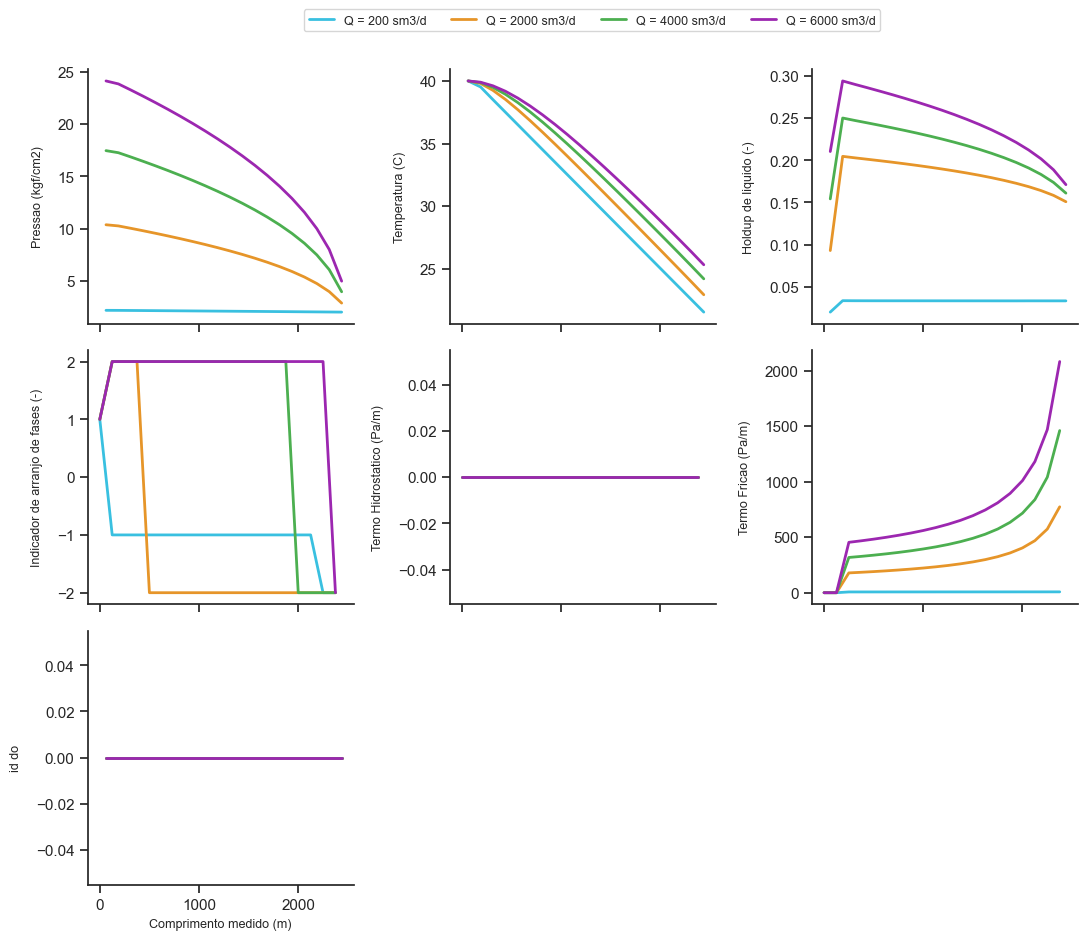

In [16]:
cenarios_h.plotar_perfis();

#### Casos verticais

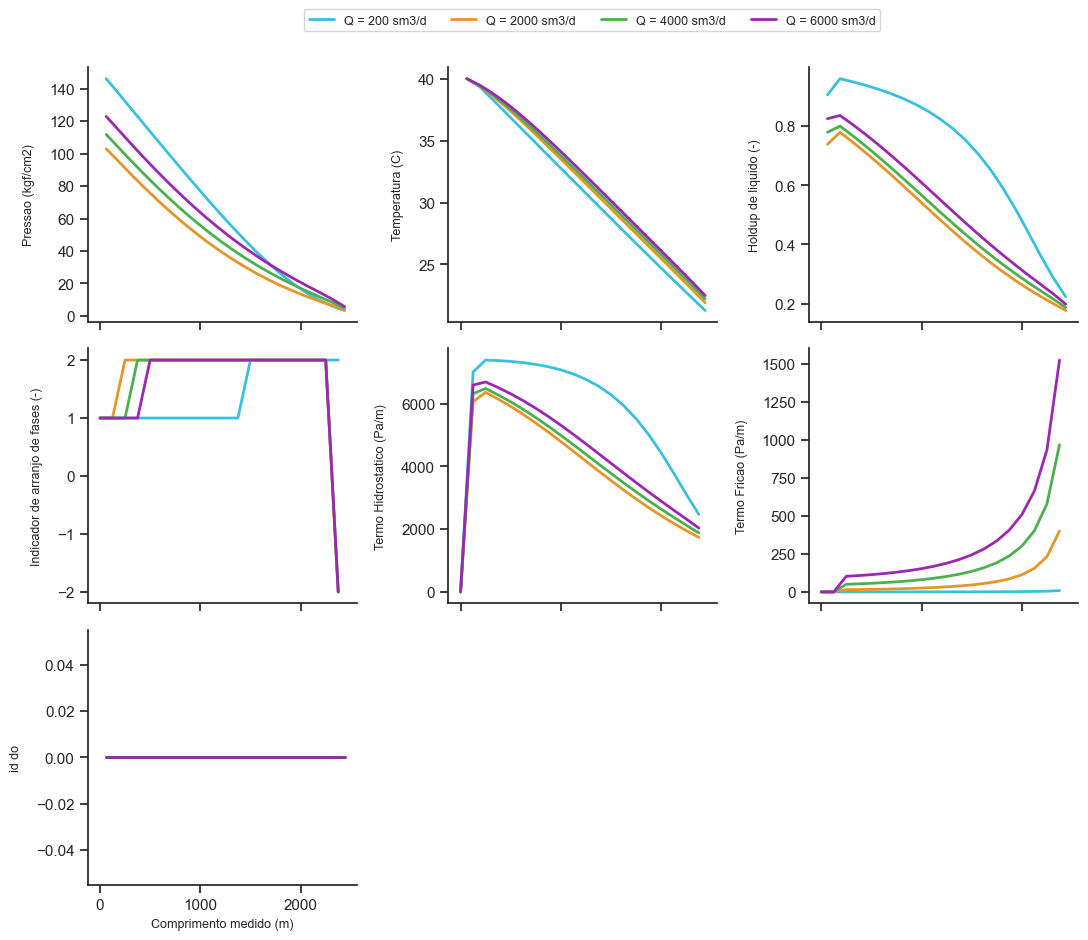

In [17]:
cenarios_v.plotar_perfis();

Se for o seu primeiro contato com resultados do tipo, analise-os e tire um tempo para pensar sobre eles antes de ler as explicações abaixo!!

* **Caso horizontal**
    * **Pressão**: quanto maior a vazão, maior é a pressão a montante associada à pressão a jusante da condição de contorno. Ou seja, maior é a diferença de pressões e, portanto, maior a perda de carga. Isso se deve à maior perda de energia do escoamento devido ao fenômeno de fricção quando os fluidos escoam com mais velocidade.
    * **Temperatura**: quanto maior a vazão, maior é a temperatura na chegada, pois um aumento na massa do fluido resulta em uma maior capacidade térmica, resultando em menor diminuição da temperatura.
    * ***Holdup***: quanto maior a vazão, maior a pressão a montante resultante e o fluido nessa condição tem menos gás livre, por isso maior é o *holdup*. Conforme o fluido escoa, a pressão cai e o gás vai sendo liberado paulatinamente, diminuindo o *holdup*. Para casos da vazão muito baixa, como $200$ sm$^3$/d, o *holdup* é praticamente constante, pois a variação de pressão é muito baixa.
    * **Arranjo de fases**: em vazões muito baixas, como $200$ sm$^3$/d, o escoamento é estratificado (-1). Vazões mais altas resultam em maior arraste de líquido e, portanto, arranjos como anular (-2), *churn* (-2) ou golfada (2).
    * **Termo hidrostático da perda de carga**: como a tubulação é horizontal, não há resistência da gravidade ao escoamento e, portanto, não há termo hidrostático na perda de carga.
    * **Termo de fricção da perda de carga**: quanto maior a vazão, maiores as velocidades de escoamento e, portanto, mais o fluido perde enegia por conta do fenômeno de fricção.

No caso vertical, há um balanço entre as parcelas de fricção e hidrostática da perda de carga, levando a comportamentos diferentes do escoamento horizontal.
      
* **Caso vertical**
    * **Pressão**: analisando apenas as três curvas de maiores vazões, o comportamento é semelhante ao caso horizontal. No entanto, repare que a menor vazão, de $200$ sm$^3$/d, corresponde à maior perda de carga! Isso ocorre porque nesse caso a vazão é tão baixa que o gás não consegue carrear o líquido, que se acumula na coluna, aumentando muito o *holdup* e consequentemente também a perda de carga por hidrostática, como verificado nos demais gráficos.
    * **Temperatura**: a tendência é parecida com a do caso horizontal, mas as curvas para as várias vazões são mais próximas. Como a queda de pressão é alta, há uma grande variação de *holdup* e o mecanismo dominante para a diminuição da temperatura não é mais a troca térmica com o ambiente e sim a expansão do gás (efeito Joule-Thompson); por isso, a menor sensibilidade em relação à vazão.
    * ***Holdup***: os *holdups* iniciais são mais altos do que no caso horizontal, já que as pressões a montante resultantes são maiores. Para entender a inversão de tendência no caso da vazão muito baixa, consulte o primeiro item (pressão).
    * **Arranjo de fases**: para a vazão mais baixa, o arranjo predominante é o bolha (1), de maior *holdup*. Para as mais altas vazões, predomina o arranjo golfada (2).
    * **Termo hidrostático da perda de carga**: o termo hidrostático da perda de carga passa a existir, já que o escoamento precisa vencer a força da gravidade para acontecer. Para entender a inversão de tendência no caso da vazão muito baixa, consulte o primeiro item (pressão).
    * **Termo de fricção da perda de carga**: o comportamento é praticamente o mesmo que no caso horizontal, mas com valores menores, já que as velocidades de escoamento são menores no caso vertical. Isso ocorre porque, no caso vertical, o escoamento apresenta *holdups* maiores para uma mesma vazão mássica; portanto, o volume específico da mistura é menor, diminuindo a vazão volumétrica e em consequência a velocidade.

## Faça você também!

**1**. Repita as análises anteriores utilizando mais variáveis de perfis na saída para visualização. Por exemplo, visualize as velocidades locais de escoamento do gás e do líquido para verificar as relações com o termo de fricção da perda de carga e o holdup mencionadas anteriormente. Consulte o JSON Schema disponível no repositório do Marlim 3 para conhecer as possíveis variáveis de saída que podem compor os perfis.

**2**. Usando como vazão de entrada $1500$ sm$^3$/d, execute novas simulações variando as seguintes propriedades:

* Diâmetro da linha ($5$" a $20$");
* Razão gás-óleo, RGO ($0$ a $2000$ Sm$^3$/Sm$^3$, com maior quantidade de simulações na faixa inicial);
* Densidade do óleo, API ($15$ a $25$°).

Qual você espera que seja o comportamento da perda de carga em cada um dos casos? Em quais deles você acha que haverá inversão de tendência devido ao balanço entre hidrostática e fricção no escoamento vertical?

**3**. Adicione uma camada a mais na seção transversal da tubulação, com características isolantes. Quais os efeitos nos perfis de temperatura de cada um dos casos?